Lacy Dove, Michael Beyer, Aryan Sanan, Harelle Keli

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Data and Aggregate DF

In [ ]:
import pandas as pd

POS_CASH_balance = pd.read_csv('/content/drive/MyDrive/AML/POS_CASH_balance.csv')
installments_payments = pd.read_csv('/content/drive/MyDrive/AML/installments_payments.csv')
previous_application= pd.read_csv('/content/drive/MyDrive/AML/previous_application.csv')
application_train = pd.read_csv('/content/drive/MyDrive/AML/application_train.csv')
credit_card_balance = pd.read_csv('/content/drive/MyDrive/AML/credit_card_balance.csv')
bureau = pd.read_csv('/content/drive/MyDrive/AML/bureau.csv')
bureau_balance = pd.read_csv('/content/drive/MyDrive/AML/bureau_balance.csv')
application_test = pd.read_csv('/content/drive/MyDrive/AML/application_test.csv')

In [ ]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,bb_MONTHS_BALANCE_min,bb_MONTHS_BALANCE_max,bb_MONTHS_BALANCE_mean,bb_MONTHS_BALANCE_count,bb_STATUS_<lambda>
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
bureau_balance.head(50)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
5,5715448,-5,C
6,5715448,-6,C
7,5715448,-7,C
8,5715448,-8,C
9,5715448,-9,0


In [ ]:
bureau_balance_agg = bureau_balance.groupby("SK_ID_BUREAU").agg({
    "MONTHS_BALANCE": ["min", "max", "mean", "count"],
    "STATUS": lambda x: x.value_counts().index[0]
})

bureau_balance_agg.columns = ["bb_" + "_".join(col) for col in bureau_balance_agg.columns]
bureau_balance_agg.reset_index(inplace=True)

# Merge into bureau
bureau = bureau.merge(bureau_balance_agg, on="SK_ID_BUREAU", how="left")


In [ ]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,bb_MONTHS_BALANCE_min,bb_MONTHS_BALANCE_max,bb_MONTHS_BALANCE_mean,bb_MONTHS_BALANCE_count
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05,774354.000000,774354.000000,774354.000000,774354.000000
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04,-36.288669,-6.062975,-21.175822,31.225694
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05,25.449736,15.064299,17.304289,23.483837
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00,-96.000000,-95.000000,-95.000000,1.000000
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00,-53.000000,0.000000,-30.000000,12.000000
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00,-31.000000,0.000000,-17.000000,25.000000
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04,-15.000000,0.000000,-8.000000,45.000000
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08,0.000000,0.000000,0.000000,97.000000


In [ ]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "DAYS_CREDIT": ["mean", "min", "max"],
    "AMT_CREDIT_SUM": ["mean", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "sum"],
    "bb_MONTHS_BALANCE_count": "sum"
})

bureau_agg.columns = ["bureau_" + "_".join(col) for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

In [ ]:
previous_agg = previous_application.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean", "sum"],
    "AMT_CREDIT": ["mean", "sum"],
    "NAME_CONTRACT_STATUS": lambda x: (x == "Approved").mean()
})

previous_agg.columns = ["prev_" + "_".join(col) for col in previous_agg.columns]
previous_agg.reset_index(inplace=True)

In [ ]:
pos_agg = POS_CASH_balance.groupby("SK_ID_CURR").agg({
    "MONTHS_BALANCE": ["mean", "count"],
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"]
})

pos_agg.columns = ["pos_" + "_".join(col) for col in pos_agg.columns]
pos_agg.reset_index(inplace=True)

In [ ]:
cc_agg = credit_card_balance.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean"],
    "SK_DPD": ["mean", "max"],
    "SK_DPD_DEF": ["mean", "max"]
})

cc_agg.columns = ["cc_" + "_".join(col) for col in cc_agg.columns]
cc_agg.reset_index(inplace=True)


In [ ]:
inst_agg = installments_payments.groupby("SK_ID_CURR").agg({
    "AMT_PAYMENT": ["mean", "sum"],
    "AMT_INSTALMENT": ["mean", "sum"],
    "DAYS_ENTRY_PAYMENT": ["mean"],
    "DAYS_INSTALMENT": ["mean"]
})

inst_agg.columns = ["inst_" + "_".join(col) for col in inst_agg.columns]
inst_agg.reset_index(inplace=True)

In [ ]:
train_df = application_train.copy()

train_df = train_df.merge(bureau_agg, on="SK_ID_CURR", how="left")
train_df = train_df.merge(previous_agg, on="SK_ID_CURR", how="left")
train_df = train_df.merge(pos_agg, on="SK_ID_CURR", how="left")
train_df = train_df.merge(cc_agg, on="SK_ID_CURR", how="left")
train_df = train_df.merge(inst_agg, on="SK_ID_CURR", how="left")

In [ ]:
test_df = application_test.copy()

test_df = test_df.merge(bureau_agg, on="SK_ID_CURR", how="left")
test_df = test_df.merge(previous_agg, on="SK_ID_CURR", how="left")
test_df = test_df.merge(pos_agg, on="SK_ID_CURR", how="left")
test_df = test_df.merge(cc_agg, on="SK_ID_CURR", how="left")
test_df = test_df.merge(inst_agg, on="SK_ID_CURR", how="left")

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df

Train shape: (307511, 154)
Test shape: (48744, 153)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,cc_SK_DPD_mean,cc_SK_DPD_max,cc_SK_DPD_DEF_mean,cc_SK_DPD_DEF_max,inst_AMT_PAYMENT_mean,inst_AMT_PAYMENT_sum,inst_AMT_INSTALMENT_mean,inst_AMT_INSTALMENT_sum,inst_DAYS_ENTRY_PAYMENT_mean,inst_DAYS_INSTALMENT_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,11559.247105,219625.695,11559.247105,219625.695,-315.421053,-295.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,64754.586000,1618864.650,64754.586000,1618864.650,-1385.320000,-1378.160000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,7096.155000,21288.465,7096.155000,21288.465,-761.666667,-754.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,62947.088438,1007153.415,62947.088438,1007153.415,-271.625000,-252.250000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,12214.060227,806127.975,12666.444545,835985.340,-1032.242424,-1028.606061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,7492.924286,52450.470,7492.924286,52450.470,-156.285714,-120.000000
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,10069.867500,60419.205,10069.867500,60419.205,-2393.833333,-2391.000000
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,NaN,NaN,NaN,NaN,4115.915357,57622.815,4399.707857,61595.910,-2387.428571,-2372.928571
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,NaN,NaN,NaN,10239.832895,194556.825,10239.832895,194556.825,-161.263158,-142.263158


# Summary Statistics and Feature Engineering
To simulate real-world approval conditioning, we will construct a synthetic “rejected” population by withholding outcome labels for a subset of applicants based on modeled approval rules.

First I want to understand the data in its raw form now that it's been aggregated.

In [ ]:
# === Check missing values ===
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_count = train_df.isnull().sum()
num_missing_cols = (train_df.isnull().sum() > 0).sum()

print ("=== Summary Statistics ===")
sum_stats=train_df.describe()
print(sum_stats)

print("===== Initial data shape =====")
print(train_df.shape)

print("\n===== Num of TARGET labels =====")
print(train_df["TARGET"].value_counts())

print("\n===== Data types =====")
print(train_df.dtypes.value_counts())

print("\n===== Missing values =====")
print("Columns with missing values:", num_missing_cols, "out of", train_df.shape[1])
print("Missing values per column:")
print(missing)

print("\n===== Duplicate rows =====")
print("Num of duplicate rows: ", train_df.duplicated().sum())

print()
train_df.head()

=== Summary Statistics ===
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05   
max    456255.000000       1.000000      19.000000      1.170000e+08   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307499.000000     3.072330e+05   
mean   5.990260e+05   27108.573909     5.383962e+05   
std    4.024908e+05   14493.737315     3.694465e+05   
min    4.500000e+04    1615.500000     4.050000e+04   
25%    2.700000e+05   16524.000000     2.385000e+

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,cc_SK_DPD_mean,cc_SK_DPD_max,cc_SK_DPD_DEF_mean,cc_SK_DPD_DEF_max,inst_AMT_PAYMENT_mean,inst_AMT_PAYMENT_sum,inst_AMT_INSTALMENT_mean,inst_AMT_INSTALMENT_sum,inst_DAYS_ENTRY_PAYMENT_mean,inst_DAYS_INSTALMENT_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,11559.247105,219625.695,11559.247105,219625.695,-315.421053,-295.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,64754.586000,1618864.650,64754.586000,1618864.650,-1385.320000,-1378.160000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,7096.155000,21288.465,7096.155000,21288.465,-761.666667,-754.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,62947.088438,1007153.415,62947.088438,1007153.415,-271.625000,-252.250000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,12214.060227,806127.975,12666.444545,835985.340,-1032.242424,-1028.606061


Ok these are some great initial stats to indicate where we might need to clean up the data in pre-processing.


*   We have 307k rows with 154 variables.
*   Looking at our target variable, we have approx 8% of the population that has defaulted (target=1). This data set is very unbalanced (as expected). We will need to handle that in our modelling.
*   We have 99 columns that have missing values. We will explore missingness and patterns to either impute or drop. Several of these look to be on the same number of rows (which accounts for approx 2/3 of the data set). We will dig in to why these are missing in such a mass prevalence.
*   We see that there are no duplicate rows. Each loan is unique.
*   Days employed seems to have negative and extraordinarily high quantities- we will need to figure out if there are any patterns and handle this.
*   Days_birth is a negative value- this indicates the age (days since birth) - we will need to remember this when we are using this column.
*   The max value for children is 19.....that's a LOT of kids..... whew.



Let's dive into who the data set represents.

In [ ]:
import numpy as np
df = train_df.copy()

# Convert age
df["AGE"] = (df["DAYS_BIRTH"] / -365).astype(int)

# Convert employment
df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan) / -365
#the last one gets rid of a single value that had over 1000 years employed.

In [ ]:
def demographic_summary(df, col):
    summary = df.groupby(col)["TARGET"].agg(["count", "mean"])
    summary["default_rate"] = summary["mean"] * 100
    return summary.sort_values("default_rate", ascending=False)

In [ ]:
(demographic_summary(df, "CODE_GENDER"))

,count,mean,default_rate
CODE_GENDER,,,
M,105059,0.101419,10.141920
F,202448,0.069993,6.999328
XNA,4,0.000000,0.000000


Twice as many women hold contracts as men, and they default less frequently than men.

In [ ]:
demographic_summary(df, "NAME_EDUCATION_TYPE")

,count,mean,default_rate
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,0.109277,10.927673
Secondary / secondary special,218391,0.089399,8.939929
Incomplete higher,10277,0.084850,8.484966
Higher education,74863,0.053551,5.355115
Academic degree,164,0.018293,1.829268


The highest default risk is going to be from people who don't have their high school diploma, followed by high school graduates/GED holders. Those who completed college were 3% less likely to default than the next closest category.

In [ ]:
demographic_summary(df, "NAME_FAMILY_STATUS")

,count,mean,default_rate
NAME_FAMILY_STATUS,,,
Civil marriage,29775,0.099446,9.944584
Single / not married,45444,0.098077,9.807675
Separated,19770,0.081942,8.194234
Married,196432,0.075599,7.559868
Widow,16088,0.058242,5.824217
Unknown,2,0.000000,0.000000


196k applicants were married, by and large representing the largest group of applicants. The next largest group were single/not married applicants.

Those in a civil marriage were most likely to default, followed by single/not married and separated applicants

In [ ]:
demographic_summary(df, "OCCUPATION_TYPE")

,count,mean,default_rate
OCCUPATION_TYPE,,,
Low-skill Laborers,2093,0.171524,17.152413
Drivers,18603,0.113261,11.326130
Waiters/barmen staff,1348,0.112760,11.275964
Security staff,6721,0.107424,10.742449
Laborers,55186,0.105788,10.578770
Cooking staff,5946,0.104440,10.443996
Sales staff,32102,0.096318,9.631799
Cleaning staff,4653,0.096067,9.606705
Realty agents,751,0.078562,7.856192


In [ ]:
demographic_summary(df, "NAME_HOUSING_TYPE")

,count,mean,default_rate
NAME_HOUSING_TYPE,,,
Rented apartment,4881,0.123131,12.313051
With parents,14840,0.116981,11.698113
Municipal apartment,11183,0.085397,8.539748
Co-op apartment,1122,0.079323,7.932264
House / apartment,272868,0.077957,7.795711
Office apartment,2617,0.065724,6.572411


In [ ]:
df["AGE_BIN"] = pd.cut(df["AGE"], bins=[20,30,40,50,60,70])

demographic_summary(df, "AGE_BIN")

/tmp/ipykernel_22939/1594035866.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(col)["TARGET"].agg(["count", "mean"])


,count,mean,default_rate
AGE_BIN,,,
"(20, 30]",52805,0.113985,11.398542
"(30, 40]",83117,0.092869,9.286909
"(40, 50]",74401,0.075510,7.550974
"(50, 60]",67819,0.059334,5.933440
"(60, 70]",29368,0.049203,4.920321


In [ ]:
df["INCOME_BIN"] = pd.qcut(df["AMT_INCOME_TOTAL"], 5)

demographic_summary(df, "INCOME_BIN")

/tmp/ipykernel_22939/1594035866.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(col)["TARGET"].agg(["count", "mean"])


,count,mean,default_rate
INCOME_BIN,,,
"(135000.0, 162000.0]",35453,0.086847,8.684738
"(99000.0, 135000.0]",85756,0.085883,8.588320
"(25649.999, 99000.0]",63671,0.082062,8.206248
"(162000.0, 225000.0]",75513,0.080569,8.056891
"(225000.0, 117000000.0]",47118,0.065198,6.519801


In [ ]:
df["EMPLOY_BIN"] = pd.cut(df["YEARS_EMPLOYED"], bins=[0,2,5,10,20,40])

demographic_summary(df, "EMPLOY_BIN")

/tmp/ipykernel_22939/1594035866.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(col)["TARGET"].agg(["count", "mean"])


,count,mean,default_rate
EMPLOY_BIN,,,
"(0, 2]",59825,0.112010,11.201003
"(2, 5]",76484,0.100779,10.077925
"(5, 10]",64872,0.073714,7.371439
"(10, 20]",38398,0.055133,5.513308
"(20, 40]",12322,0.042607,4.260672


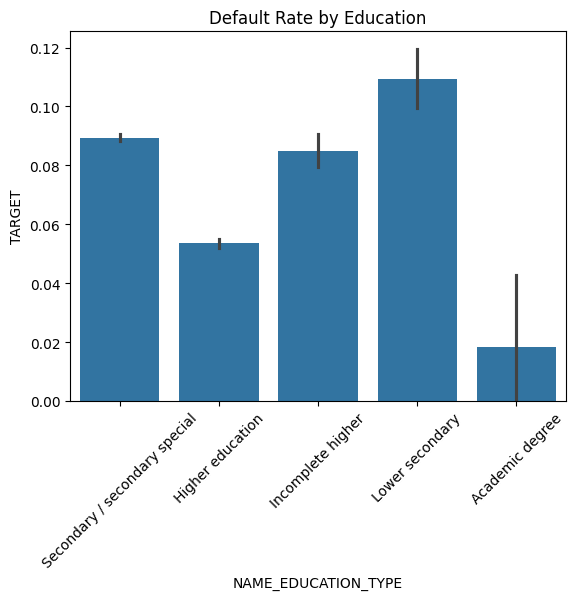

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="NAME_EDUCATION_TYPE",
    y="TARGET"
)
plt.xticks(rotation=45)
plt.title("Default Rate by Education")
plt.show()

In [ ]:
pivot = pd.pivot_table(
    df,
    values="TARGET",
    index=["AGE_BIN", "NAME_EDUCATION_TYPE"],
    columns="EMPLOY_BIN",
    aggfunc=("mean", "count")
)

pivot

/tmp/ipykernel_22939/3742152901.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


count                          \
EMPLOY_BIN                             (0, 2] (2, 5] (5, 10] (10, 20]   
AGE_BIN  NAME_EDUCATION_TYPE                                            
(20, 30] Academic degree                    8      7       2        0   
         Higher education                5991   6652    3571      274   
         Incomplete higher               2013   1989     828       55   
         Lower secondary                  161    159      91        5   
         Secondary / secondary special  11001  12931    6376      520   
(30, 40] Academic degree                   14     10      20        8   
         Higher education                5381   6847    6916     4367   
         Incomplete higher                742    933     828      419   
         Lower secondary                  275    313     242      153   
         Secondary / secondary special  12897  17183   15454     8891   
(40, 50] Academic degree                    7      9      11       17   
         Higher education                3109   4103    4146     3537   
         Incomplete higher                287    391     416      227   
         Lower secondary                  108    150     118       86   
         Secondary / secondary special  10543  14397   14472    10377   
(50, 60] Academic degree                    5      5       2        7   
         Higher education                1459   1981    2217     1987   
         Incomplete higher                 87    128     132      104   
         Lower secondary                   59     91      77       56   
         Secondary / secondary special   5068   7258    7848     6324   
(60, 70] Academic degree                    1      0       1        1   
         Higher education                 140    226     294      295   
         Incomplete higher                 11     13      10        9   
         Lower secondary                    9     15      20       19   
         Secondary / secondary special    449    692     780      660   

                                                     mean                      \
EMPLOY_BIN                             (20, 40]    (0, 2]    (2, 5]   (5, 10]   
AGE_BIN  NAME_EDUCATION_TYPE                                                    
(20, 30] Academic degree                      0  0.000000  0.000000  0.000000   
         Higher education                     0  0.072108  0.066747  0.062167   
         Incomplete higher                    0  0.097864  0.096531  0.097826   
         Lower secondary                      0  0.186335  0.150943  0.131868   
         Secondary / secondary special        0  0.156622  0.144923  0.108846   
(30, 40] Academic degree                      0  0.000000  0.200000  0.050000   
         Higher education                   163  0.073221  0.061925  0.041932   
         Incomplete higher                   16  0.105121  0.084673  0.074879   
         Lower secondary                      8  0.185455  0.185304  0.107438   
         Secondary / secondary special      473  0.136233  0.123785  0.091627   
(40, 50] Academic degree                      2  0.000000  0.000000  0.000000   
         Higher education                  1441  0.079447  0.055325  0.046310   
         Incomplete higher                   62  0.090592  0.076726  0.072115   
         Lower secondary                     24  0.064815  0.120000  0.152542   
         Secondary / secondary special     4136  0.110026  0.096548  0.074281   
(50, 60] Academic degree                      1  0.000000  0.000000  0.000000   
         Higher education                  1291  0.065798  0.066128  0.044204   
         Incomplete higher                   48  0.091954  0.046875  0.060606   
         Lower secondary                     39  0.135593  0.098901  0.142857   
         Secondary / secondary special     3950  0.090174  0.085147  0.063965   
(60, 70] Academic degree                      0  0.000000       NaN  0.000000   
         Higher education                   231  0.

First and foremost, we see that age drives everything.  
- Younger borrowers are significantly higher risk, regardless of education or employment.  
- Education is a strong risk differentiator, especially among younger borrowers.  
- Education matters less as borrowers age—risk converges across groups.  
- Employment stability reduces default risk, especially in mid-age groups.  
- The biggest risk drop is graduating from 0-2 to 5-10 years in employment.   
- The highest-risk borrowers are young, low-education individuals with limited employment history.  
- Extremely low default rates for highly educated borrowers may reflect small sample sizes rather than true risk.  
- Extreme values in small subgroups highlight the importance of considering sample size in EDA.  
- Even well-educated younger borrowers exhibit elevated default risk, suggesting age and financial maturity play a critical role.

In [ ]:
df["INCOME_BIN"] = pd.qcut(df["AMT_INCOME_TOTAL"], 5) # allows us to look at economic power
df["DEBT_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"] #credit burden - higher here is higher risk
df["CHILDREN_BIN"] = pd.cut(df["CNT_CHILDREN"], bins=[-1,0,2,5,10]) # this should capture financial obligations, can couple with single v married

In [ ]:
df["DTI_BIN"] = pd.qcut(df["DEBT_TO_INCOME"], 5)

pd.pivot_table(
    df,
    values="TARGET",
    index=["AGE_BIN", "NAME_EDUCATION_TYPE"],
    columns="DTI_BIN",
    aggfunc="mean"
)

/tmp/ipykernel_22939/1370449950.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


DTI_BIN                                 (-0.000776, 0.104]  (0.104, 0.144]  \
AGE_BIN  NAME_EDUCATION_TYPE                                                 
(20, 30] Academic degree                          0.000000        0.000000   
         Higher education                         0.062036        0.065338   
         Incomplete higher                        0.075417        0.096349   
         Lower secondary                          0.095238        0.121951   
         Secondary / secondary special            0.109128        0.138713   
(30, 40] Academic degree                          0.055556        0.000000   
         Higher education                         0.045084        0.049109   
         Incomplete higher                        0.079343        0.076246   
         Lower secondary                          0.104972        0.122093   
         Secondary / secondary special            0.094989        0.107561   
(40, 50] Academic degree                          0.000000        0.000000   
         Higher education                         0.045444        0.051029   
         Incomplete higher                        0.043732        0.075472   
         Lower secondary                          0.065934        0.135417   
         Secondary / secondary special            0.082661        0.079196   
(50, 60] Academic degree                          0.000000        0.000000   
         Higher education                         0.042477        0.040580   
         Incomplete higher                        0.064748        0.036585   
         Lower secondary                          0.053097        0.083871   
         Secondary / secondary special            0.062234        0.062381   
(60, 70] Academic degree                          0.000000        0.000000   
         Higher education                         0.041825        0.040854   
         Incomplete higher                        0.021739        0.038462   
         Lower secondary                          0.060870        0.051724   
         Secondary / secondary special            0.048942        0.052632   

DTI_BIN                                 (0.144, 0.186]  (0.186, 0.247]  \
AGE_BIN  NAME_EDUCATION_TYPE                                             
(20, 30] Academic degree                      0.000000        0.000000   
         Higher education                     0.066839        0.069187   
         Incomplete higher                    0.108954        0.114094   
         Lower secondary                      0.182927        0.179775   
         Secondary / secondary special        0.140447        0.157173   
(30, 40] Academic degree                      0.153846        0.000000   
         Higher education                     0.057420        0.060273   
         Incomplete higher                    0.095575        0.093809   
         Lower secondary                      0.169811        0.189076   
         Secondary / secondary special        0.109133        0.119163   
(40, 50] Academic degree                      0.000000        0.000000   
         Higher education                     0.059125        0.047927   
         Incomplete higher                    0.089041        0.079848   
         Lower secondary                      0.119565        0.106557   
         Secondary / secondary special        0.082783        0.084782   
(50, 60] Academic degree                      0.000000        0.000000   
         Higher education                     0.048809        0.046745   
         Incomplete higher                    0.055172        0.048276   
         Lower secondary                      0.061453        0.093264   
         Secondary / secondary special        0.060733        0.067244   
(60, 70] Academic degree                      0.000000        0.000000   
         Higher education                     0.031959        0.025586   
         Incomplete higher                    0.057692        0.042553   
         Lower secondary                   

- Default risk increases consistently with debt-to-income ratio, with the strongest effect among younger and lower-education borrowers.  
- Debt-to-income ratio amplifies baseline demographic risk rather than acting independently.  
- The highest-risk borrowers are young individuals with low education and high financial burden.  
- The impact of debt burden decreases with age, suggesting older borrowers are more resilient to financial stress.  
- While education reduces baseline risk, high debt burden can offset its protective effect.
- Extremely low default rates among highly educated borrowers should be interpreted cautiously due to likely small sample sizes.
  
Takeaway: Debt burden does not affect all borrowers equally—it disproportionately increases risk among younger and less-educated individuals, while older borrowers remain relatively stable even at higher debt levels

In [ ]:
pd.pivot_table(
    df,
    values="TARGET",
    index=["NAME_HOUSING_TYPE"],
    columns="AGE_BIN",
    aggfunc="mean"
)

/tmp/ipykernel_22939/46140599.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


AGE_BIN,"(20, 30]","(30, 40]","(40, 50]","(50, 60]","(60, 70]"
NAME_HOUSING_TYPE,,,,,
Co-op apartment,0.121469,0.077612,0.042918,0.049296,0.051724
House / apartment,0.111782,0.090785,0.074270,0.058485,0.048806
Municipal apartment,0.124638,0.097570,0.082587,0.069025,0.054409
Office apartment,0.076923,0.071680,0.053245,0.050228,0.082873
Rented apartment,0.129600,0.128766,0.117509,0.094972,0.057692
With parents,0.121818,0.113261,0.110315,0.105134,0.027397


- Borrowers with less stable housing situations (renting, municipal housing, living with parents) exhibit higher default rates compared to homeowners.  
- Renting is the most consistently high-risk housing category, likely reflecting lower financial stability and fewer assets.  
-  Age remains the dominant predictor of default, with risk decreasing consistently across all housing types.  
- Housing type matters less as borrowers age, suggesting that financial stability increases over time regardless of housing status.  
- Living with parents is associated with elevated default risk among younger borrowers, but this relationship reverses in older age groups, likely due to differing life circumstances.  
- Municipal housing reflects moderate financial risk—higher than ownership but lower than renting—suggesting intermediate socioeconomic stability.  
  
Big Takeaway: Housing type serves as a proxy for financial stability, with renters and non-owners consistently exhibiting higher default risk—particularly among younger borrowers where economic vulnerability is greatest.  


In [ ]:
df["EXT_MEAN"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

df["EXT_BIN"] = pd.qcut(df["EXT_MEAN"], 5)

In [ ]:
# Combine external scores
df["EXT_MEAN"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

# Optional: also create min/max (sometimes useful)
df["EXT_MIN"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].min(axis=1)
df["EXT_MAX"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].max(axis=1)

# Bin it
df["EXT_BIN"] = pd.qcut(df["EXT_MEAN"], 5, duplicates="drop")

#Credit to income ratio work:
df["CREDIT_TO_INCOME"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]

# Bin it
df["CREDIT_TO_INCOME_BIN"] = pd.qcut(df["CREDIT_TO_INCOME"], 5, duplicates="drop")

#Income Stability
# Check categories
df["NAME_INCOME_TYPE"].value_counts()

# Optional: simplify categories (recommended)
income_map = {
    "Working": "Working",
    "Commercial associate": "Working",
    "State servant": "Stable",
    "Pensioner": "Pensioner",
    "Unemployed": "Unemployed",
    "Student": "Other",
    "Businessman": "Other",
    "Maternity leave": "Other"
}

df["INCOME_TYPE_GROUP"] = df["NAME_INCOME_TYPE"].map(income_map)

#Family structure
# Children bins
df["CHILDREN_BIN"] = pd.cut(
    df["CNT_CHILDREN"],
    bins=[-1, 0, 2, 5, 10],
    labels=["0", "1-2", "3-5", "6+"]
)

# Optional: simplify family status
family_map = {
    "Married": "Married",
    "Civil marriage": "Married",
    "Single / not married": "Single",
    "Separated": "Single",
    "Widow": "Single",
    "Unknown": "Other"
}

df["FAMILY_STATUS_GROUP"] = df["NAME_FAMILY_STATUS"].map(family_map)

#Socioeconomic proxy - Region
# Already numeric but you can bin it
df["REGION_BIN"] = pd.cut(
    df["REGION_RATING_CLIENT"],
    bins=[0, 1, 2, 3],
    labels=["Low", "Mid", "High"]
)

In [ ]:
pd.pivot_table(
    df,
    values="TARGET",
    index=["NAME_HOUSING_TYPE"],
    columns=["CREDIT_TO_INCOME_BIN"],
    aggfunc="mean"
)

/tmp/ipykernel_22939/237288066.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


CREDIT_TO_INCOME_BIN,"(0.00381, 1.818]","(1.818, 2.764]","(2.764, 3.906]","(3.906, 5.769]","(5.769, 84.737]"
NAME_HOUSING_TYPE,,,,,
Co-op apartment,0.086957,0.085106,0.099057,0.082126,0.041860
House / apartment,0.071175,0.082365,0.086147,0.079669,0.070453
Municipal apartment,0.079091,0.088839,0.093866,0.084642,0.080905
Office apartment,0.036545,0.074951,0.083665,0.078067,0.059829
Rented apartment,0.101844,0.130783,0.133401,0.134454,0.120863
With parents,0.096466,0.122485,0.129598,0.133750,0.107241


In [ ]:
def risk_pivot(df, index, columns, values="TARGET", aggfunc="mean"):
    return pd.pivot_table(
        df,
        values=values,
        index=index,
        columns=columns,
        aggfunc=aggfunc
    )

In [ ]:
pivot_ext_age = risk_pivot(df, "AGE_BIN", "EXT_BIN")
pivot_ext_age

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


EXT_BIN,"(-0.00099406, 0.384]","(0.384, 0.484]","(0.484, 0.564]","(0.564, 0.644]","(0.644, 0.879]"
AGE_BIN,,,,,
"(20, 30]",0.188740,0.089794,0.060478,0.046337,0.036654
"(30, 40]",0.214121,0.099205,0.062024,0.037921,0.027952
"(40, 50]",0.200361,0.104128,0.062556,0.040853,0.024750
"(50, 60]",0.152921,0.082230,0.052319,0.039066,0.022480
"(60, 70]",0.110571,0.069502,0.052194,0.034018,0.021265


In [ ]:
pivot_ext_edu = risk_pivot(df, "NAME_EDUCATION_TYPE", "EXT_BIN")
pivot_ext_edu

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


EXT_BIN,"(-0.00099406, 0.384]","(0.384, 0.484]","(0.484, 0.564]","(0.564, 0.644]","(0.644, 0.879]"
NAME_EDUCATION_TYPE,,,,,
Academic degree,0.037037,0.066667,0.000000,0.000000,0.000000
Higher education,0.149518,0.071423,0.041756,0.026161,0.017255
Incomplete higher,0.170785,0.076409,0.052454,0.044135,0.025797
Lower secondary,0.192271,0.122120,0.074074,0.045886,0.047273
Secondary / secondary special,0.196970,0.100198,0.065369,0.044361,0.027790


In [ ]:
pivot_cti_age = risk_pivot(df, "AGE_BIN", "CREDIT_TO_INCOME_BIN")
pivot_cti_age

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


CREDIT_TO_INCOME_BIN,"(0.00381, 1.818]","(1.818, 2.764]","(2.764, 3.906]","(3.906, 5.769]","(5.769, 84.737]"
AGE_BIN,,,,,
"(20, 30]",0.095238,0.119464,0.130972,0.121848,0.106814
"(30, 40]",0.080627,0.098534,0.105034,0.096595,0.083333
"(40, 50]",0.070670,0.079174,0.084969,0.074271,0.068720
"(50, 60]",0.052947,0.062053,0.059446,0.063571,0.057564
"(60, 70]",0.039788,0.039736,0.049319,0.055108,0.062076


In [ ]:
pivot_cti_house = risk_pivot(df, "NAME_HOUSING_TYPE", "CREDIT_TO_INCOME_BIN")
pivot_cti_house

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


CREDIT_TO_INCOME_BIN,"(0.00381, 1.818]","(1.818, 2.764]","(2.764, 3.906]","(3.906, 5.769]","(5.769, 84.737]"
NAME_HOUSING_TYPE,,,,,
Co-op apartment,0.086957,0.085106,0.099057,0.082126,0.041860
House / apartment,0.071175,0.082365,0.086147,0.079669,0.070453
Municipal apartment,0.079091,0.088839,0.093866,0.084642,0.080905
Office apartment,0.036545,0.074951,0.083665,0.078067,0.059829
Rented apartment,0.101844,0.130783,0.133401,0.134454,0.120863
With parents,0.096466,0.122485,0.129598,0.133750,0.107241


In [ ]:
pivot_income_ext = risk_pivot(df, "INCOME_TYPE_GROUP", "EXT_BIN")
pivot_income_ext

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


EXT_BIN,"(-0.00099406, 0.384]","(0.384, 0.484]","(0.484, 0.564]","(0.564, 0.644]","(0.644, 0.879]"
INCOME_TYPE_GROUP,,,,,
Other,0.000000,0.333333,0.000000,0.000000,0.000000
Pensioner,0.128610,0.071397,0.047703,0.035741,0.020782
Stable,0.149740,0.072639,0.042060,0.028145,0.017386
Unemployed,0.555556,0.333333,0.000000,0.000000,0.400000
Working,0.200045,0.098859,0.063185,0.041661,0.027108


In [ ]:
pivot_family_cti = risk_pivot(df, "FAMILY_STATUS_GROUP", "CREDIT_TO_INCOME_BIN")
pivot_family_cti

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


CREDIT_TO_INCOME_BIN,"(0.00381, 1.818]","(1.818, 2.764]","(2.764, 3.906]","(3.906, 5.769]","(5.769, 84.737]"
FAMILY_STATUS_GROUP,,,,,
Married,0.071324,0.082937,0.088609,0.080709,0.070846
Other,0.000000,NaN,0.000000,NaN,NaN
Single,0.077635,0.091864,0.090952,0.089411,0.080568


In [ ]:
pivot_region_ext = risk_pivot(df, "REGION_BIN", "EXT_BIN")
pivot_region_ext

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


EXT_BIN,"(-0.00099406, 0.384]","(0.384, 0.484]","(0.484, 0.564]","(0.564, 0.644]","(0.644, 0.879]"
REGION_BIN,,,,,
Low,0.165402,0.088538,0.045582,0.031009,0.019898
Mid,0.182226,0.091960,0.059652,0.039816,0.025405
High,0.205547,0.099171,0.064338,0.045217,0.032214


In [ ]:
pivot_children_cti = risk_pivot(df, "CHILDREN_BIN", "CREDIT_TO_INCOME_BIN")
pivot_children_cti

/tmp/ipykernel_22939/566350586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  return pd.pivot_table(


CREDIT_TO_INCOME_BIN,"(0.00381, 1.818]","(1.818, 2.764]","(2.764, 3.906]","(3.906, 5.769]","(5.769, 84.737]"
CHILDREN_BIN,,,,,
0,0.071900,0.083036,0.083991,0.078576,0.068219
1-2,0.076080,0.091503,0.100997,0.092728,0.082250
3-5,0.084806,0.094059,0.107399,0.103203,0.106502
6+,0.111111,0.166667,0.625000,0.000000,0.166667


In [ ]:
def plot_default_by_category(df, category, title, order=None):
    summary = df.groupby(category)["TARGET"].agg(["mean", "count"]).sort_values("mean", ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=summary.index, y=summary["mean"])
    plt.title(title)
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return summary

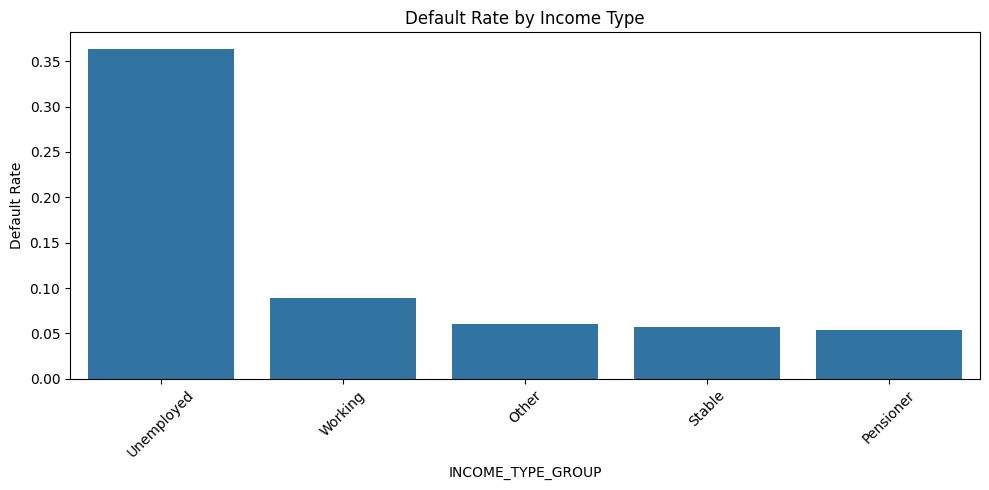

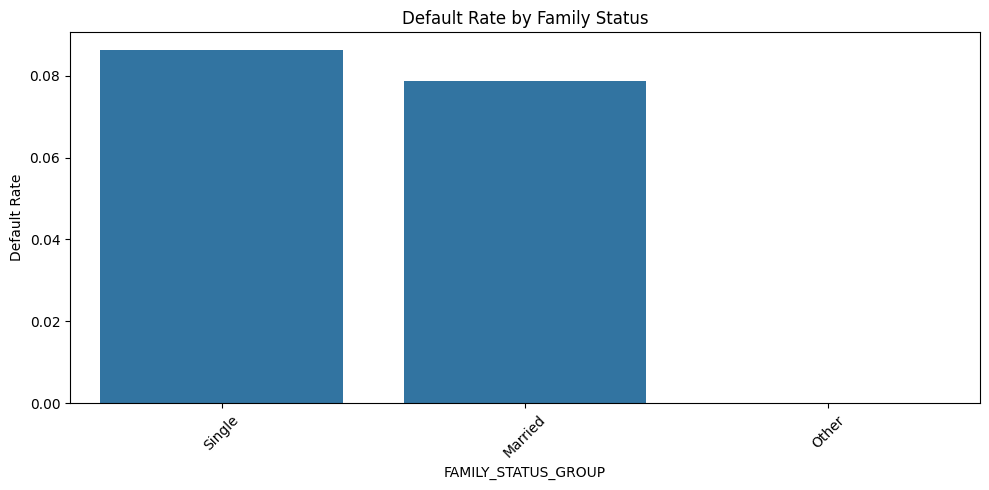

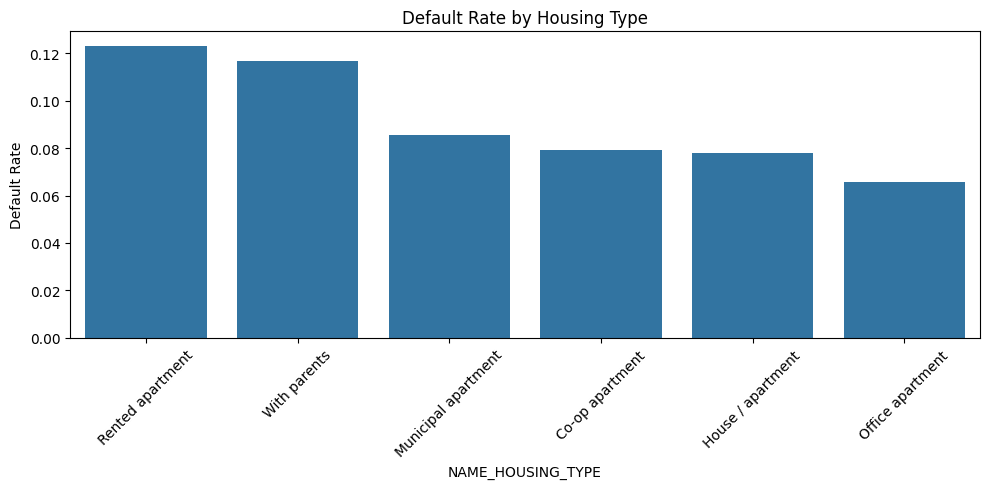

/tmp/ipykernel_22939/3258150467.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(category)["TARGET"].agg(["mean", "count"]).sort_values("mean", ascending=False)


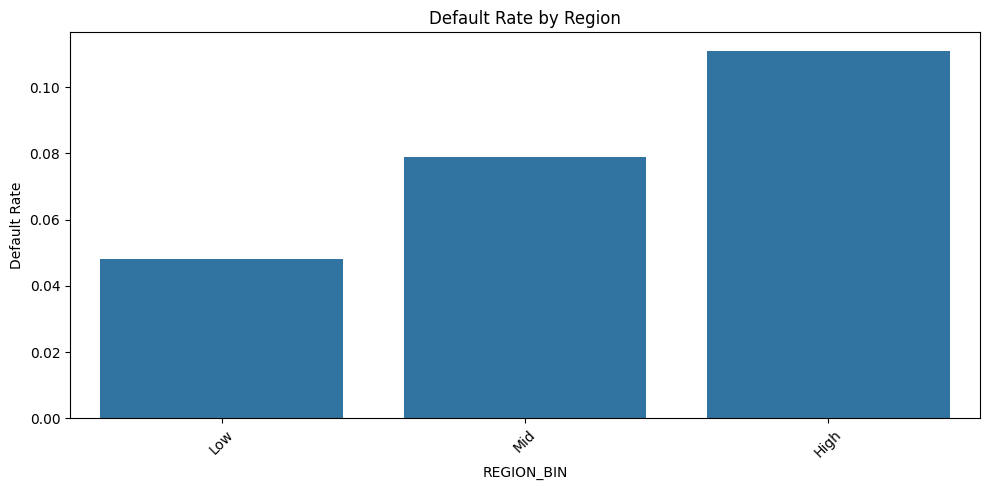

,mean,count
REGION_BIN,,
High,0.111028,48330
Mid,0.078891,226984
Low,0.048203,32197


In [ ]:
plot_default_by_category(df, "INCOME_TYPE_GROUP", "Default Rate by Income Type")
plot_default_by_category(df, "FAMILY_STATUS_GROUP", "Default Rate by Family Status")
plot_default_by_category(df, "NAME_HOUSING_TYPE", "Default Rate by Housing Type")
plot_default_by_category(df, "REGION_BIN", "Default Rate by Region")

In [ ]:
def plot_risk_heatmap(df, index, columns, title, figsize=(10, 6)):
    pivot_mean = pd.pivot_table(
        df, values="TARGET", index=index, columns=columns, aggfunc="mean"
    )

    pivot_count = pd.pivot_table(
        df, values="TARGET", index=index, columns=columns, aggfunc="count"
    ).reindex(index=pivot_mean.index, columns=pivot_mean.columns)

    annot = pivot_mean.copy().astype(object)

    for i in range(pivot_mean.shape[0]):
        for j in range(pivot_mean.shape[1]):
            m = pivot_mean.iloc[i, j]
            n = pivot_count.iloc[i, j]
            if pd.notnull(m) and pd.notnull(n):
                annot.iloc[i, j] = f"{m*100:.1f}%\n(n={int(n)})"
            else:
                annot.iloc[i, j] = ""

    plt.figure(figsize=figsize)
    sns.heatmap(
        pivot_mean,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        linewidths=0.5
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_22939/2242097000.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = pd.pivot_table(
/tmp/ipykernel_22939/2242097000.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = pd.pivot_table(


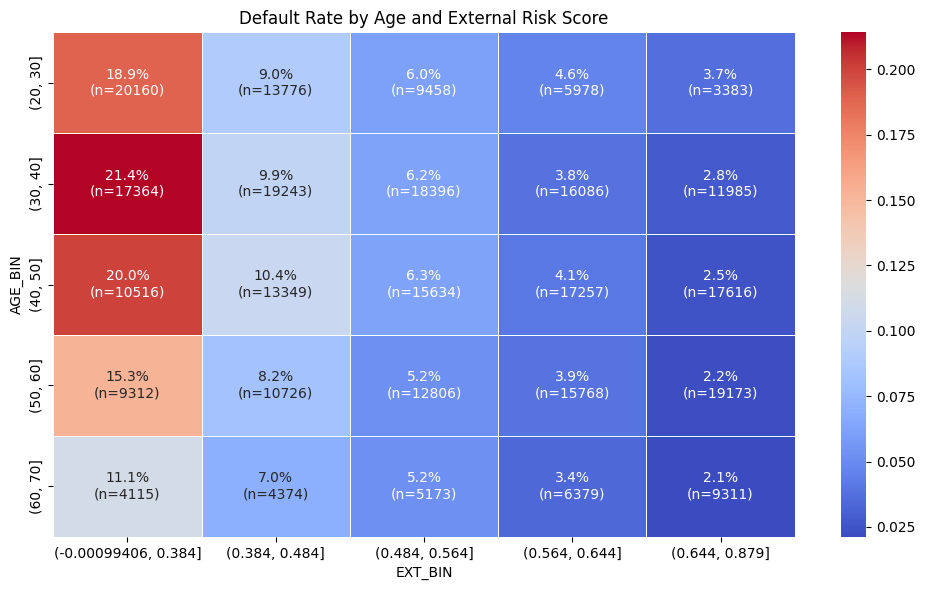

/tmp/ipykernel_22939/2242097000.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = pd.pivot_table(
/tmp/ipykernel_22939/2242097000.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = pd.pivot_table(


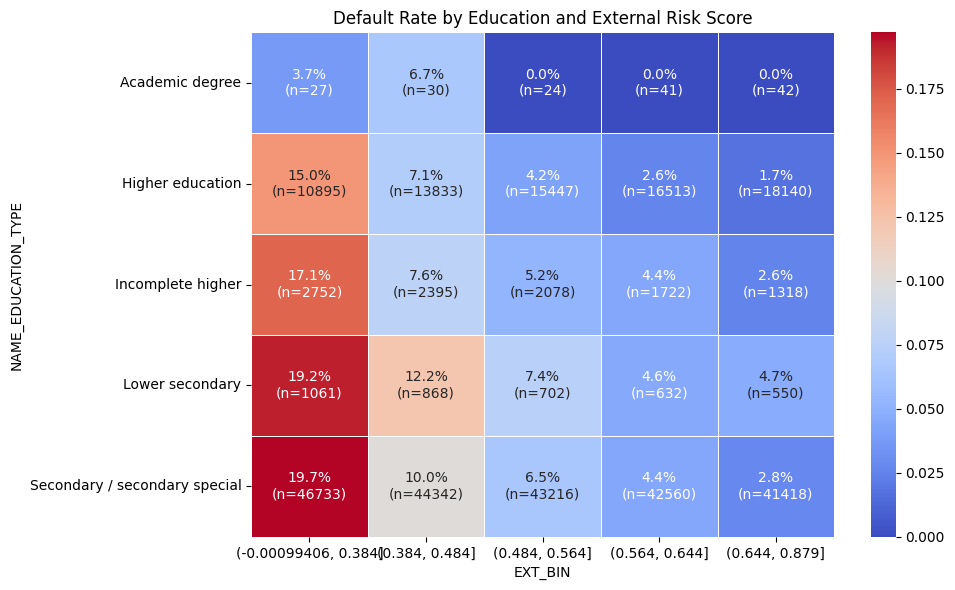

/tmp/ipykernel_22939/2242097000.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = pd.pivot_table(
/tmp/ipykernel_22939/2242097000.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = pd.pivot_table(


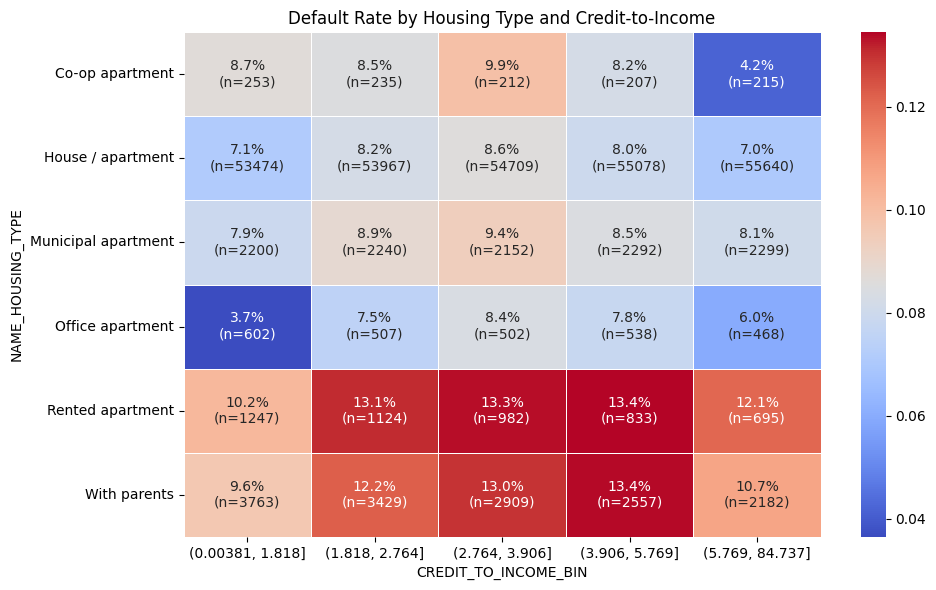

/tmp/ipykernel_22939/2242097000.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = pd.pivot_table(
/tmp/ipykernel_22939/2242097000.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = pd.pivot_table(


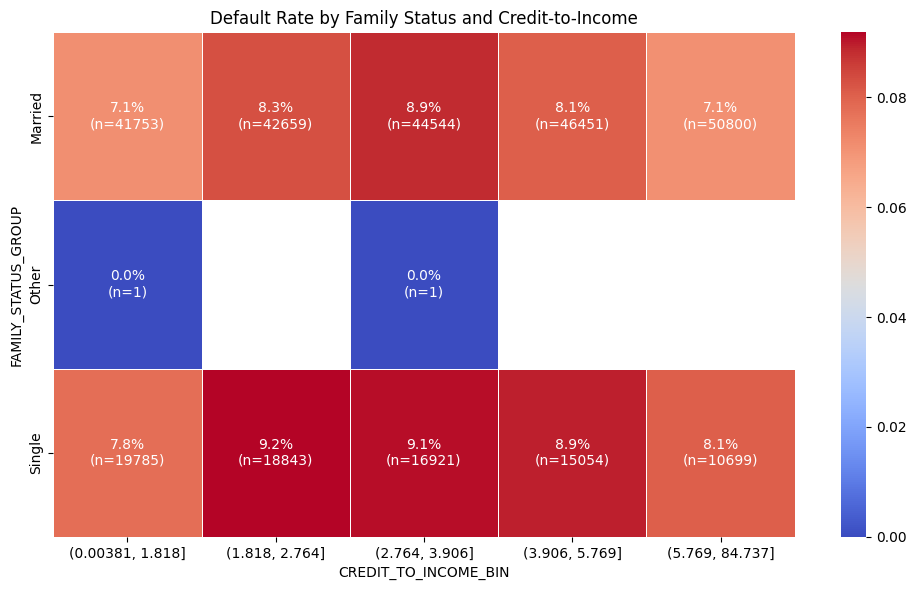

In [ ]:
plot_risk_heatmap(df, "AGE_BIN", "EXT_BIN", "Default Rate by Age and External Risk Score")
plot_risk_heatmap(df, "NAME_EDUCATION_TYPE", "EXT_BIN", "Default Rate by Education and External Risk Score")
plot_risk_heatmap(df, "NAME_HOUSING_TYPE", "CREDIT_TO_INCOME_BIN", "Default Rate by Housing Type and Credit-to-Income")
plot_risk_heatmap(df, "FAMILY_STATUS_GROUP", "CREDIT_TO_INCOME_BIN", "Default Rate by Family Status and Credit-to-Income")

- External risk scores are the strongest single predictor of default, consistently separating high- and low-risk borrowers across all demographic groups.  
- Age sets the baseline level of risk, with younger borrowers consistently exhibiting higher default rates regardless of other factors.  
- Financial burden amplifies existing risk rather than acting independently, with the strongest impact among already vulnerable groups.  
- Housing type serves as a proxy for financial stability, with renters and non-owners consistently exhibiting higher default rates.  
- Household structure influences default risk by increasing financial obligations and reducing economic resilience.  
- Income stability is more predictive of default risk than income level alone.  
- Regional differences contribute to default risk but are secondary to individual financial and demographic factors.  
  
Big Takeaway: Risk is not driven by a single factor—it emerges from the interaction of baseline vulnerability (age, education), financial stress (CTI/DTI), and stability (housing, income type), with external risk scores capturing and amplifying these underlying dynamics.  
  
    
Risk Profile:   
**High-risk borrower**

*   Young (20–35)
*   Lower education
*   High CTI / DTI
*   Renting / unstable housing
*   Working (less stable income)
*   Low EXT score  
  
**Low-risk borrower**

*   Older (40+)
*   Higher education
*   Low CTI / DTI
*   Owns home
*   Stable income (pensioner/state)
*   High EXT score

Next we build a synthetic "Reject" population with the insights we have aggregated.

APPROVAL THRESHOLD: 1.5386
Overall approval rate: 0.635
Observed default rate among approved: 0.0506
True default rate among rejected: 0.1332

Approval rate by AGE_BIN:
          APPROVED
AGE_BIN           
(20, 30]     0.364
(30, 40]     0.576
(40, 50]     0.709
(50, 60]     0.768
(60, 70]     0.797

Approval rate by EXT_BIN:
                      APPROVED
EXT_BIN                       
(-0.00099406, 0.384]     0.168
(0.384, 0.484]           0.515
(0.484, 0.564]           0.735
(0.564, 0.644]           0.847
(0.644, 0.879]           0.911

Approval rate by housing:
                     APPROVED
NAME_HOUSING_TYPE            
Co-op apartment         0.587
House / apartment       0.653
Municipal apartment     0.624
Office apartment        0.610
Rented apartment        0.426
With parents            0.390

Approval rate by education:
                               APPROVED
NAME_EDUCATION_TYPE                    
Academic degree                   0.756
Higher education                  0.73

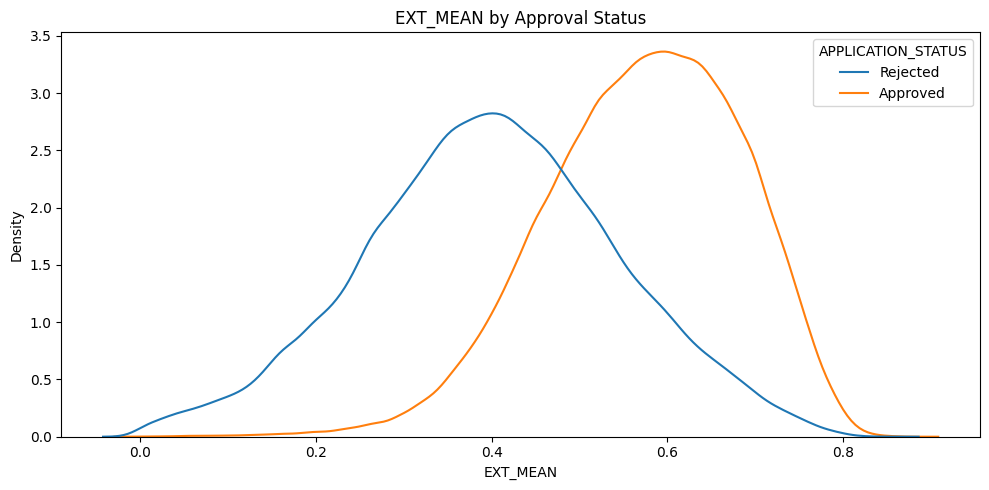

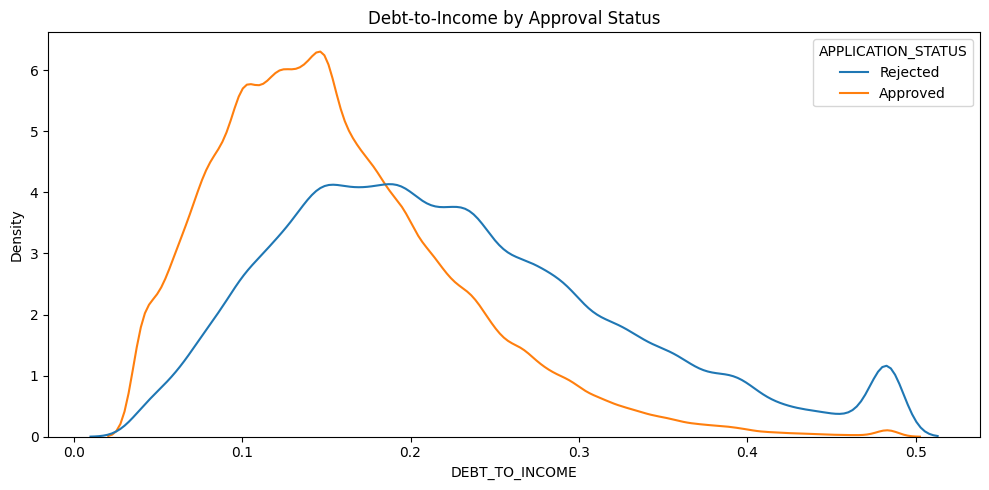

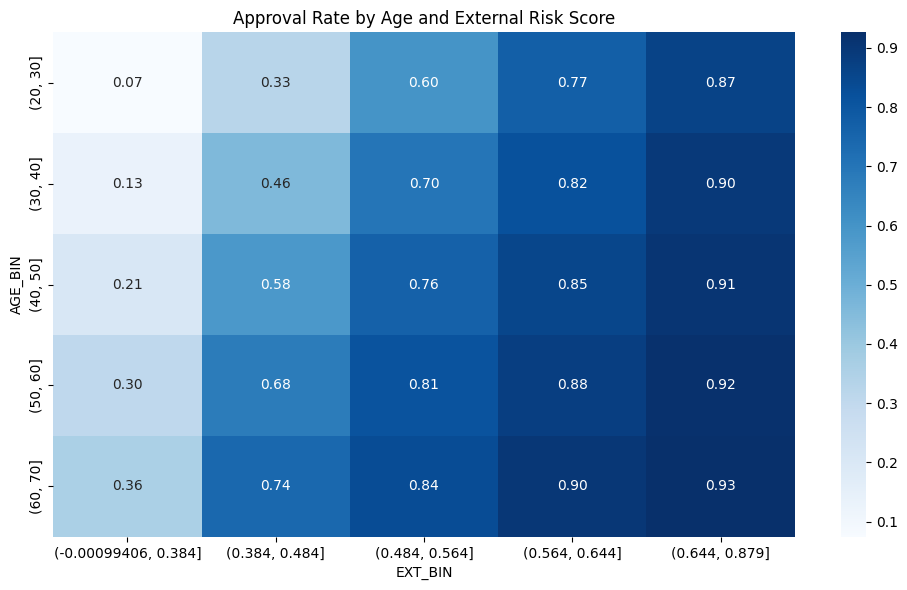

In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import zscore

# -----------------------------
# 1) Copy data
# -----------------------------
sim_df = df.copy()

# -----------------------------
# 2) Basic cleanup / feature prep
# -----------------------------
# Age in years
if "AGE" not in sim_df.columns:
    sim_df["AGE"] = (-sim_df["DAYS_BIRTH"] / 365).round(0)

# Employment in years
if "YEARS_EMPLOYED" not in sim_df.columns:
    sim_df["YEARS_EMPLOYED"] = sim_df["DAYS_EMPLOYED"].replace(365243, np.nan) / -365

# External score
if "EXT_MEAN" not in sim_df.columns:
    sim_df["EXT_MEAN"] = sim_df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

# Debt-to-income ratio
if "DEBT_TO_INCOME" not in sim_df.columns:
    sim_df["DEBT_TO_INCOME"] = sim_df["AMT_ANNUITY"] / sim_df["AMT_INCOME_TOTAL"]

# Credit-to-income ratio
if "CREDIT_TO_INCOME" not in sim_df.columns:
    sim_df["CREDIT_TO_INCOME"] = sim_df["AMT_CREDIT"] / sim_df["AMT_INCOME_TOTAL"]

# Guard against infinities
for col in ["DEBT_TO_INCOME", "CREDIT_TO_INCOME", "EXT_MEAN", "YEARS_EMPLOYED", "AGE"]:
    sim_df[col] = sim_df[col].replace([np.inf, -np.inf], np.nan)

# Clip extreme affordability ratios to reduce distortion
sim_df["DEBT_TO_INCOME"] = sim_df["DEBT_TO_INCOME"].clip(
    lower=sim_df["DEBT_TO_INCOME"].quantile(0.01),
    upper=sim_df["DEBT_TO_INCOME"].quantile(0.99)
)

sim_df["CREDIT_TO_INCOME"] = sim_df["CREDIT_TO_INCOME"].clip(
    lower=sim_df["CREDIT_TO_INCOME"].quantile(0.01),
    upper=sim_df["CREDIT_TO_INCOME"].quantile(0.99)
)

# Fill continuous vars with medians for underwriting score construction
score_num_cols = ["EXT_MEAN", "DEBT_TO_INCOME", "CREDIT_TO_INCOME", "AGE", "YEARS_EMPLOYED"]
for col in score_num_cols:
    sim_df[col] = sim_df[col].fillna(sim_df[col].median())

# -----------------------------
# 3) Standardize numeric risk drivers
# -----------------------------
sim_df["z_ext"] = zscore(sim_df["EXT_MEAN"])
sim_df["z_dti"] = zscore(sim_df["DEBT_TO_INCOME"])
sim_df["z_cti"] = zscore(sim_df["CREDIT_TO_INCOME"])
sim_df["z_age"] = zscore(sim_df["AGE"])
sim_df["z_emp"] = zscore(sim_df["YEARS_EMPLOYED"])

# -----------------------------
# 4) Encode categorical stability / risk flags
#    These follow the patterns from your EDA
# -----------------------------
sim_df["young_flag"] = (sim_df["AGE"] < 35).astype(int)
sim_df["older_flag"] = (sim_df["AGE"] >= 50).astype(int)

sim_df["low_edu_flag"] = sim_df["NAME_EDUCATION_TYPE"].isin(
    ["Lower secondary", "Secondary / secondary special"]
).astype(int)

sim_df["higher_edu_flag"] = sim_df["NAME_EDUCATION_TYPE"].isin(
    ["Higher education", "Academic degree"]
).astype(int)

sim_df["renter_flag"] = sim_df["NAME_HOUSING_TYPE"].eq("Rented apartment").astype(int)
sim_df["municipal_flag"] = sim_df["NAME_HOUSING_TYPE"].eq("Municipal apartment").astype(int)
sim_df["with_parents_flag"] = sim_df["NAME_HOUSING_TYPE"].eq("With parents").astype(int)
sim_df["owned_flag"] = sim_df["NAME_HOUSING_TYPE"].eq("House / apartment").astype(int)

sim_df["stable_income_flag"] = sim_df["NAME_INCOME_TYPE"].isin(
    ["State servant", "Pensioner"]
).astype(int)

sim_df["working_flag"] = sim_df["NAME_INCOME_TYPE"].isin(
    ["Working", "Commercial associate"]
).astype(int)

sim_df["single_flag"] = sim_df["NAME_FAMILY_STATUS"].isin(
    ["Single / not married", "Separated", "Widow"]
).astype(int)

sim_df["children_flag"] = (sim_df["CNT_CHILDREN"] >= 2).astype(int)

# Region: higher rating number is typically worse context
sim_df["region_worse_flag"] = (sim_df["REGION_RATING_CLIENT"] >= 3).astype(int)

# -----------------------------
# 5) Composite underwriting score
#    Lower score = more approvable
#    Weights emphasize what your EDA found:
#    EXT strongest, then affordability, then stability
# -----------------------------
sim_df["underwriting_score"] = (
    # strongest driver
    -2.4 * sim_df["z_ext"] +

    # affordability / burden
    1.25 * sim_df["z_dti"] +
    0.90 * sim_df["z_cti"] +

    # age / stability
    -0.55 * sim_df["z_age"] +
    -0.45 * sim_df["z_emp"] +

    # categorical adjustments
    0.55 * sim_df["young_flag"] +
    -0.30 * sim_df["older_flag"] +
    0.55 * sim_df["low_edu_flag"] +
    -0.30 * sim_df["higher_edu_flag"] +
    0.45 * sim_df["renter_flag"] +
    0.20 * sim_df["municipal_flag"] +
    0.25 * sim_df["with_parents_flag"] +
    -0.25 * sim_df["owned_flag"] +
    -0.25 * sim_df["stable_income_flag"] +
    0.18 * sim_df["working_flag"] +
    0.20 * sim_df["single_flag"] +
    0.15 * sim_df["children_flag"] +
    0.12 * sim_df["region_worse_flag"]
)

# Add realistic underwriting noise so approvals are not perfectly deterministic
rng = np.random.default_rng(42)
sim_df["underwriting_score_noisy"] = sim_df["underwriting_score"] + rng.normal(0, 0.35, len(sim_df))

# -----------------------------
# 6) Convert score to approval probability
#    Tune intercept to get a realistic approval rate
# -----------------------------

target_approval_rate = 0.65
flip_prob = 0.05


# This is the exact cutoff that determines approval
approval_threshold = sim_df["underwriting_score_noisy"].quantile(target_approval_rate)

# Initial deterministic approval rule
sim_df["APPROVED"] = (sim_df["underwriting_score_noisy"] <= approval_threshold).astype(int)

# =========================================================
# REALISM: random overrides
# This simulates imperfect real-world underwriting:
# - some risky applicants still get approved
# - some safer applicants still get declined
# =========================================================
rng = np.random.default_rng(42)

flip_mask = rng.random(len(sim_df)) < flip_prob
sim_df.loc[flip_mask, "APPROVED"] = 1 - sim_df.loc[flip_mask, "APPROVED"]

# Human-readable label
sim_df["APPLICATION_STATUS"] = np.where(sim_df["APPROVED"] == 1, "Approved", "Rejected")

# =========================================================
# STEP 7: HIDE TARGET FOR REJECTED APPLICANTS
# This creates the synthetic "reject inference" setup
# =========================================================
sim_df["TARGET_OBSERVED"] = sim_df["TARGET"].where(sim_df["APPROVED"] == 1, np.nan)

# =========================================================
# STEP 8: VALIDATION
# =========================================================
print("APPROVAL THRESHOLD:", round(approval_threshold, 4))
print("Overall approval rate:", round(sim_df["APPROVED"].mean(), 3))
print("Observed default rate among approved:", round(sim_df.loc[sim_df["APPROVED"] == 1, "TARGET"].mean(), 4))
print("True default rate among rejected:", round(sim_df.loc[sim_df["APPROVED"] == 0, "TARGET"].mean(), 4))

print("\nApproval rate by AGE_BIN:")
print(pd.pivot_table(sim_df, values="APPROVED", index="AGE_BIN", aggfunc="mean", observed=False).round(3))

print("\nApproval rate by EXT_BIN:")
print(pd.pivot_table(sim_df, values="APPROVED", index="EXT_BIN", aggfunc="mean", observed=False).round(3))

print("\nApproval rate by housing:")
print(pd.pivot_table(sim_df, values="APPROVED", index="NAME_HOUSING_TYPE", aggfunc="mean").round(3))

print("\nApproval rate by education:")
print(pd.pivot_table(sim_df, values="APPROVED", index="NAME_EDUCATION_TYPE", aggfunc="mean").round(3))

# =========================================================
# QUICK VISUAL CHECKS
# =========================================================

plt.figure(figsize=(10, 5))
sns.kdeplot(data=sim_df, x="EXT_MEAN", hue="APPLICATION_STATUS", common_norm=False)
plt.title("EXT_MEAN by Approval Status")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=sim_df, x="DEBT_TO_INCOME", hue="APPLICATION_STATUS", common_norm=False)
plt.title("Debt-to-Income by Approval Status")
plt.tight_layout()
plt.show()

approval_heat = pd.pivot_table(
    sim_df,
    values="APPROVED",
    index="AGE_BIN",
    columns="EXT_BIN",
    aggfunc="mean",
    observed=False
)

plt.figure(figsize=(10, 6))
sns.heatmap(approval_heat, annot=True, fmt=".2f", cmap="Blues")
plt.title("Approval Rate by Age and External Risk Score")
plt.tight_layout()
plt.show()

We simulated approvals using a risk score built from the main drivers we identified in EDA—things like external risk scores, debt burden, and overall stability (age, housing, income type).

Applicants with lower risk scores are more likely to be approved, and higher-risk applicants are more likely to be rejected.

As expected, the approved group has a much lower default rate than the rejected group, which creates the same kind of selection bias you’d see in a real lending scenario.

# Pre-Processing

In [ ]:
df_miss = sim_df.copy()

missing_summary = df_miss.isnull().mean().sort_values(ascending=False)
missing_summary.head(20)

,0
cc_SK_DPD_DEF_max,0.717392
cc_SK_DPD_max,0.717392
cc_AMT_BALANCE_mean,0.717392
cc_AMT_BALANCE_max,0.717392
cc_SK_DPD_mean,0.717392
cc_AMT_CREDIT_LIMIT_ACTUAL_mean,0.717392
cc_SK_DPD_DEF_mean,0.717392
COMMONAREA_MEDI,0.698723
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723


After simulating approval decisions, missingness patterns changed significantly. Features related to credit card history became less sparse, reflecting selection bias toward applicants with more established credit profiles. In contrast, property-related features remained highly sparse, indicating structural missingness.

For the property details, missingness indicates that it is not present - given this, we will fill missing values with 0.   
  
Details about whether a car is owned are going to be filled with 0 if they are missing (indicating no car owned, therefore no age).
  
Because the EXT_SOURCE columns are such a driver in the profile for risk, this one needs to be handled so that the missing values don't skew the results. For this one, we will take the median value and fill blanks.
  
For numeric columns, we will stick with the median values to avoid issues with outliers.

In [ ]:
property_cols = [col for col in sim_df.columns if any(
    k in col for k in ["APARTMENTS", "AREA", "FLOOR", "YEARS", "COMMONAREA"]
)]
sim_df[property_cols] = sim_df[property_cols].fillna(0)
sim_df["OWN_CAR_AGE"] = sim_df["OWN_CAR_AGE"].fillna(0)
sim_df["has_car"] = (sim_df["OWN_CAR_AGE"] > 0).astype(int)
sim_df["EXT_SOURCE_1"] = sim_df["EXT_SOURCE_1"].fillna(sim_df["EXT_SOURCE_1"].median())
num_cols = sim_df.select_dtypes(include=["int64", "float64"]).columns
sim_df[num_cols] = sim_df[num_cols].fillna(sim_df[num_cols].median())

In [ ]:
df_miss = sim_df.copy()

missing_summary = df_miss.isnull().mean().sort_values(ascending=False)
missing_summary.head(20)

,0
FONDKAPREMONT_MODE,0.683862
WALLSMATERIAL_MODE,0.508408
HOUSETYPE_MODE,0.501761
EMERGENCYSTATE_MODE,0.473983
OCCUPATION_TYPE,0.313455
EMPLOY_BIN,0.180839
NAME_TYPE_SUITE,0.004201
EXT_BIN,0.000559
DTI_BIN,0.000039
CHILDREN_BIN,0.000026


The remaining values are all categorical and will be handled via one-hot encoding.

In [ ]:
# Only use approved applications for training
train_df_model = sim_df[sim_df["APPROVED"] == 1].copy()

# Drop rows with missing target (should already be handled)
train_df_model = train_df_model[train_df_model["TARGET_OBSERVED"].notnull()]

In [ ]:
train_df_model.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,"CREDIT_TO_INCOME_BIN_(5.769, 84.737]",INCOME_TYPE_GROUP_Pensioner,INCOME_TYPE_GROUP_Stable,INCOME_TYPE_GROUP_Unemployed,INCOME_TYPE_GROUP_Working,FAMILY_STATUS_GROUP_Other,FAMILY_STATUS_GROUP_Single,REGION_BIN_Mid,REGION_BIN_High,APPLICATION_STATUS_Rejected
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,False,False,True,False,False,False,False,False,False,False
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,False,False,False,False,True,False,True,True,False,False
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,False,False,False,False,True,False,False,True,False,False
6,100009,0,1,171000.0,1560726.0,41301.0,1395000.0,0.035792,-13778,-3130,...,True,False,False,False,True,False,False,True,False,False
7,100010,0,0,360000.0,1530000.0,42075.0,1530000.0,0.003122,-18850,-449,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
y = train_df_model["TARGET_OBSERVED"]

X = train_df_model.drop(columns=[
    "TARGET",
    "TARGET_OBSERVED",
    "APPROVED",
    "APPLICATION_STATUS_Rejected"
])

In [ ]:
leakage_cols = [
    "underwriting_score",
    "underwriting_score_noisy",
    "approval_logit",
    "approval_prob",
    "RISK_SCORE"
]

X = X.drop(columns=[col for col in leakage_cols if col in X.columns], errors="ignore")

In [ ]:
X=pd.get_dummies(X, drop_first=True)

Ok- I've split the data, One-hot encoded, and handled and leakage (columns that will be used to predict approval).

# Phase 1: Baseline Credit Risk Monitoring
As a baseline, we will maintain the “approved only” dataset and train Logistic Regression and Regularized Logistic Regression. The metrics we intend to use are

1.   AUC
2.   Log-Loss
3.   Calibration Curve


This analysis will establish the baseline performance and we expect will highlight bias due to sample selection.


# Phase 2: Reject Inference
This stage is focused on implementing a reject inference model using a parcelling based reject inference approach, according to the following steps:

1.   Score rejected applicants using the baseline model.
2.   Partition rejected applicants into risk bands.
3.   Assign probabilistic default labels within each band.
4.   Assign probabilistic default labels within each band.
5.   Retrain the model using augmented data.

We will then compare predictive performance, calibration, and risk distribution against the baseline model performance to show an expected increase in predictive capability over baseline.


# Phase 3: Survival Analysis
This stage enhances the modeling done in Stage 2 to layer in the temporal aspect. By nature, binary “default = 1, 0” ignores timing. In this stage, we intend to incorporate Cox Proportional Hazard model and Neural Survival Model to allow prediction of hazard rate and survivability over time. We will evaluate Stage 3 using concordance index and the integrated brier score.

These advanced regression and optimization techniques will provide a time-to-event analysis that differentiates this project from other literature previously conducted.


Team Decision: Determine what the event definition is so that everyone is on the same page.

# Phase 4: Bias-Variance Optimization Analysis
In this stage, we focus on the basics to identify the optimum model. We analyze overfitting versus underfitting, the effect of regularization at each stage, the learning rate sensitivity for the neural survival model, and calibration and robustness. With these analyses, we can proceed to the evaluation frameworks.

# Analysis and Comparison
Evaluation will be conducted using train/validation/test splits, calibration analysis, and pre- and post-reject-inference model comparisons. These diagnostics enable us to examine distributional shift, measure the extent to which selection bias distorts risk estimates, and assess model robustness under simulated changes in approval policy.


# Ethical and Regulatory Considerations
To incorporate ethical and regulatory considerations, we will include fairness diagnostics as part of model evaluation. We will compare calibration, score distributions, and error rates across demographic segments before and after applying reject inference to assess whether selection-aware modeling changes disparity patterns. This ensures that improvements in predictive performance are evaluated alongside fairness, interpretability, and regulatory defensibility.